# Process Performance Map (U-ED-LSTM DomesticDeclarations)

Visualizes model prediction performance overlaid on a process map.

- **Start node**: How many cases start with each activity
- **Node color**: Overall accuracy when predicting from this activity
- **Edge color**: Accuracy for this specific transition (green = high, red = low)
- **Edge label**: correct/total predictions

In [1]:
# Setup
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

import torch
from src.interpretability.config.domestic_declarations_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability.visualization.process_performance_map import ProcessPerformanceMap

print(f"Dataset: {CONFIG.dataset_name}")

Dataset: DomesticDeclarations


In [2]:
# === TEST MODE CONFIGURATION ===
# Set TEST_MODE = True to run on a subset of cases for faster iteration
TEST_MODE = False
CONFIG.use_improved = False  # set True for the improved variant
MAX_CASES = 100  # Number of cases to use in test mode

print(f"Test mode: {TEST_MODE}" + (f" (max {MAX_CASES} cases)" if TEST_MODE else ""))

Test mode: False


In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 10, {'APPROVED': 1, 'EOS': 2, 'FINAL_APPROVED': 3, 'FOR_APPROVAL': 4, 'Payment Handled': 5, 'REJECTED': 6, 'Request Payment': 7, 'SAVED': 8, 'SUBMITTED': 9}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Amount', 1, {})])
Encoder input features:  [['Activity', 'Resource', 'Role'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Amount']]
Decoder input+output features:  [['Activity', 'Resource'], ['case_elapsed_time', 'event_elapsed_time']]


Sequence length of decoder output:  4


Cells hidden size:  128
Number of LSTM layer:  2
Dropout rate:  0.0


Encoder number of labels for each input feature (categorical, numerical):  [[10, 4, 9], [1, 1, 1, 1

In [4]:
# Collect predictions
ppm = ProcessPerformanceMap(
    model=model,
    test_dataset=test_dataset,
    eval_helper=eval_helper,
    activity_key=CONFIG.concept_name,
    device=device
)

# Apply test mode: limit to subset of cases
if TEST_MODE:
    case_names = list(eval_helper.cases.keys())[:MAX_CASES]
    print(f"Test mode: using {len(case_names)} of {len(eval_helper.cases)} cases")
else:
    case_names = None  # Use all cases

ppm.collect_predictions(show_progress=True, case_names=case_names)


Collected 11269 predictions
Found 16 unique transitions


In [5]:
# --- Overall accuracy summary ---
from collections import Counter, defaultdict
import pandas as pd

preds = ppm.predictions
n_total = len(preds)
n_correct = sum(1 for p in preds if p.correct)
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

# Per prefix-length
by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for p in preds:
    by_plen[p.prefix_length]['total'] += 1
    by_plen[p.prefix_length]['correct'] += int(p.correct)
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

# Mean confidence (softmax argmax prob at the predicted class)
mean_conf = sum(p.confidence for p in preds) / n_total if n_total else 0.0
print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 9454/11269 = 0.8389 (83.89%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1     1594   2100  0.759048
             2     1288   2071  0.621922
             3     1809   2070  0.873913
             4     1929   2021  0.954478
             5     1656   1738  0.952819
             6      659    709  0.929478
             7      176    196  0.897959
             8      167    178  0.938202
             9      101    106  0.952830
            10       38     40  0.950000
            11       18     21  0.857143
            12       13     13  1.000000
            13        4      4  1.000000
            14        1      1  1.000000
            15        1      1  1.000000

Mean top-1 confidence: 77.68%


In [6]:
# --- Per-transition breakdown table ---
# Source activity x actual next activity, with correct/total/accuracy. This makes
# explicit which directly-follows transitions the model handles well vs. badly.
import pandas as pd
from collections import defaultdict

_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for _p in ppm.predictions:
    _key = (_p.current_activity, _p.actual_next_activity)
    _stats[_key]['total'] += 1
    _stats[_key]['correct'] += int(_p.correct)

transitions_df = pd.DataFrame([
    {'source': s, 'target': t, 'correct': v['correct'], 'total': v['total'],
     'accuracy': v['correct'] / v['total']}
    for (s, t), v in _stats.items()
]).sort_values(['source', 'total'], ascending=[True, False]).reset_index(drop=True)

print(f'{len(transitions_df)} unique transitions')
with pd.option_context('display.max_rows', None):
    display(transitions_df)


16 unique transitions


,source,target,correct,total,accuracy
0,APPROVED,FINAL_APPROVED,1679,1719,0.976731
1,APPROVED,APPROVED,12,586,0.020478
2,APPROVED,REJECTED,0,64,0.000000
3,FINAL_APPROVED,Request Payment,1998,1998,1.000000
4,FINAL_APPROVED,REJECTED,0,19,0.000000
5,FINAL_APPROVED,Payment Handled,0,2,0.000000
6,Payment Handled,EOS,1988,1999,0.994497
7,REJECTED,REJECTED,0,265,0.000000
8,REJECTED,SUBMITTED,0,224,0.000000
9,REJECTED,EOS,0,72,0.000000


In [7]:
# Create activity name mapping
label_dict = ppm.get_activity_label_dict()
activity_name_map = {str(idx): name for name, idx in label_dict.items()}

print("Activity mapping:")
for idx_str in sorted(activity_name_map.keys(), key=lambda x: int(x) if x.isdigit() else 0):
    print(f"  {idx_str}: {activity_name_map[idx_str]}")

Activity mapping:
  1: APPROVED
  2: EOS
  3: FINAL_APPROVED
  4: FOR_APPROVAL
  5: Payment Handled
  6: REJECTED
  7: Request Payment
  8: SAVED
  9: SUBMITTED


## Process Map

Filtered out 0 rare activities (< 0 occurrences)
Filtered out 0 rare directly-follows edges (< 0 occurrences)
Remaining: 8 activities, 17 edges


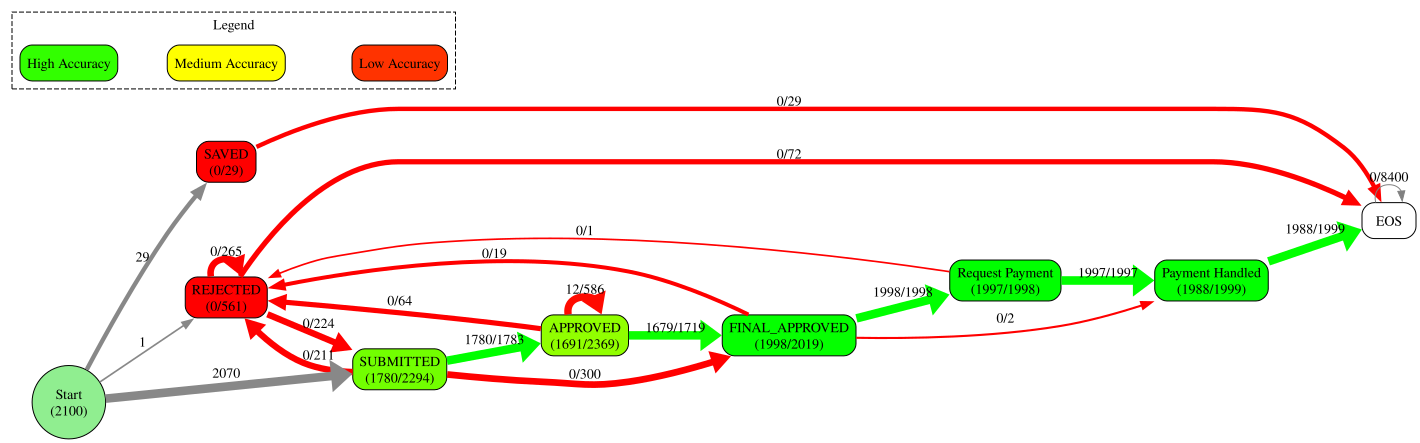

In [8]:
# ============================================
# FILTERING THRESHOLDS
# ============================================
MIN_EDGE_COUNT = 0       # hide directly-follows edges seen fewer times
MIN_ACTIVITY_COUNT = 0  # hide activities whose total occurrences fall below this

# --- Pre-filter the DFG based on thresholds ---
# Compute per-activity frequency from the DFG
if ppm.dfg is None:
    ppm.mine_dfg()

activity_freq = {}
for (src_act, tgt_act), cnt in ppm.dfg.items():
    activity_freq[src_act] = activity_freq.get(src_act, 0) + cnt
    activity_freq[tgt_act] = activity_freq.get(tgt_act, 0) + cnt

keep_activities = {a for a, c in activity_freq.items() if c >= MIN_ACTIVITY_COUNT}

# Backup original DFG so we can restore it
_original_dfg = dict(ppm.dfg)
ppm.dfg = {
    (s, t): c for (s, t), c in _original_dfg.items()
    if s in keep_activities and t in keep_activities and c >= MIN_EDGE_COUNT
}

n_removed_acts = len(activity_freq) - len(keep_activities)
n_removed_edges = len(_original_dfg) - len(ppm.dfg)
print(f'Filtered out {n_removed_acts} rare activities '
      f'(< {MIN_ACTIVITY_COUNT} occurrences)')
print(f'Filtered out {n_removed_edges} rare directly-follows edges '
      f'(< {MIN_EDGE_COUNT} occurrences)')
print(f'Remaining: {len(keep_activities)} activities, {len(ppm.dfg)} edges')

# Generate process map with filtered DFG
dot = ppm.visualize(
    min_edge_count=MIN_EDGE_COUNT,
    show_counts=True,
    activity_name_map=activity_name_map,
    show_start_node=True,
)

# Restore for any downstream analysis
ppm.dfg = _original_dfg

dot

## Interactive Explorer

In [9]:
# Interactive exploration
explorer = ppm.create_interactive_explorer(activity_name_map=activity_name_map)
explorer.show()